In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.models import resnet152, ResNet152_Weights

print("1. Initializing CUDA device for Colab...")
# Automatically targets the NVIDIA T4 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware Acceleration: {device}")

weights = ResNet152_Weights.DEFAULT
preprocess = weights.transforms()

print("2. Loading CIFAR-10 with Colab-optimized settings...")
# Increased batch size and enabled workers for much faster loading
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=preprocess)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=preprocess)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

print("3. Loading pre-trained ResNet-152...")
model = resnet152(weights=weights)

# 4. Monkey-Patching to Disable Skip Connections in Layer 4
def disable_skip_connection(bottleneck_block):
    # Store original forward method to avoid recursion issues
    original_forward = bottleneck_block.forward

    def forward_no_skip(x):
        identity = x
        out = bottleneck_block.conv1(x)
        out = bottleneck_block.bn1(out)
        out = bottleneck_block.relu(out)

        out = bottleneck_block.conv2(out)
        out = bottleneck_block.bn2(out)
        out = bottleneck_block.relu(out)

        out = bottleneck_block.conv3(out)
        out = bottleneck_block.bn3(out)

        # THIS IS THE BREAK: We intentionally DO NOT do `out += identity`
        out = bottleneck_block.relu(out)
        return out

    # Overwrite the forward pass for this specific block
    bottleneck_block.forward = forward_no_skip

print("4. Severing skip connections in layer4...")
for block in model.layer4:
    disable_skip_connection(block)

print("5. Freezing backbone and replacing head...")
for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print("6. Starting modified training loop...")
epochs = 3
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Prints every 100 batches due to the larger batch size
        if (i + 1) % 100 == 0:
            print(f"   [Epoch {epoch+1}, Batch {i+1}] Loss: {running_loss / (i+1):.4f}")

    # Validation phase to compare accuracy drops
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"=== Epoch {epoch+1} Completed | Loss: {running_loss/len(trainloader):.4f} | Validation Accuracy: {100 * correct / total:.2f}% ===")

1. Initializing CUDA device for Colab...
Hardware Acceleration: cuda
2. Loading CIFAR-10 with Colab-optimized settings...


100%|██████████| 170M/170M [22:07<00:00, 128kB/s]


3. Loading pre-trained ResNet-152...
Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 173MB/s]


4. Severing skip connections in layer4...
5. Freezing backbone and replacing head...
6. Starting modified training loop...
   [Epoch 1, Batch 100] Loss: 2.2847
   [Epoch 1, Batch 200] Loss: 2.2681
   [Epoch 1, Batch 300] Loss: 2.2538
   [Epoch 1, Batch 400] Loss: 2.2401
   [Epoch 1, Batch 500] Loss: 2.2300
   [Epoch 1, Batch 600] Loss: 2.2186
   [Epoch 1, Batch 700] Loss: 2.2078
=== Epoch 1 Completed | Loss: 2.2006 | Validation Accuracy: 29.36% ===
   [Epoch 2, Batch 100] Loss: 2.1233
   [Epoch 2, Batch 200] Loss: 2.1187
   [Epoch 2, Batch 300] Loss: 2.1155
   [Epoch 2, Batch 400] Loss: 2.1095
   [Epoch 2, Batch 500] Loss: 2.1027
   [Epoch 2, Batch 600] Loss: 2.0973
   [Epoch 2, Batch 700] Loss: 2.0920
=== Epoch 2 Completed | Loss: 2.0874 | Validation Accuracy: 31.09% ===
   [Epoch 3, Batch 100] Loss: 2.0420
   [Epoch 3, Batch 200] Loss: 2.0396
   [Epoch 3, Batch 300] Loss: 2.0393
   [Epoch 3, Batch 400] Loss: 2.0378
   [Epoch 3, Batch 500] Loss: 2.0349
   [Epoch 3, Batch 600] Loss: 2.

Running t-SNE for Early Layer (Layer 1)... this takes a few seconds.
Running t-SNE for Middle Layer (Layer 3)... this takes a few seconds.
Running t-SNE for Late Layer (AvgPool)... this takes a few seconds.


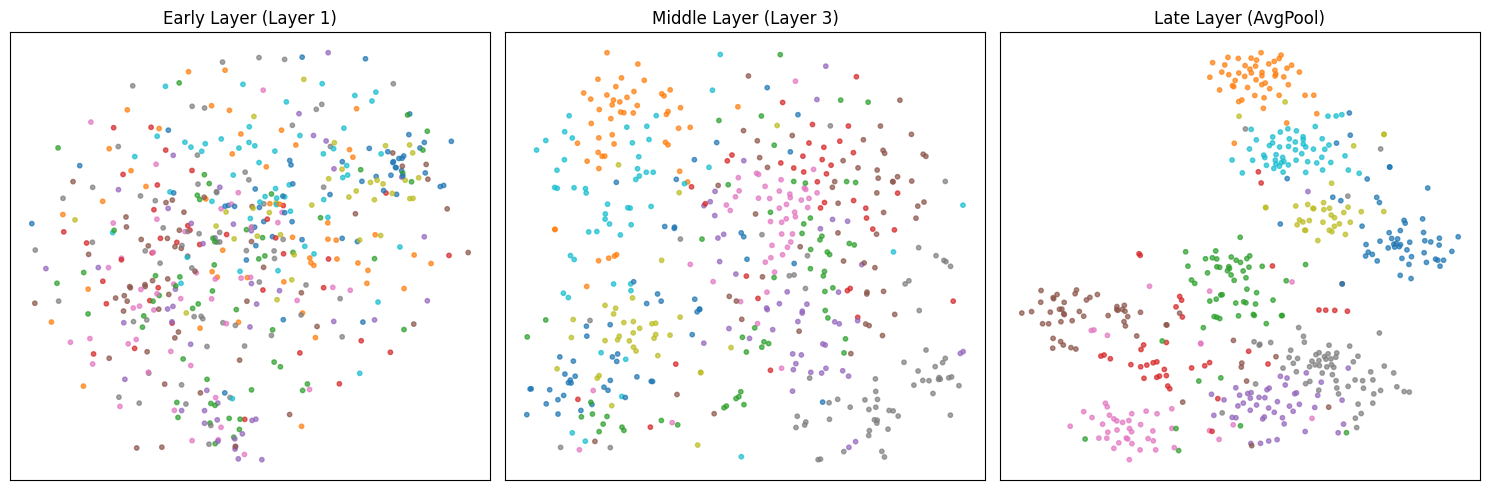

In [ ]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from torchvision.models import resnet152, ResNet152_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load Pre-trained Model (using cached data/weights)
weights = ResNet152_Weights.DEFAULT
model = resnet152(weights=weights).to(device)
model.eval()

preprocess = weights.transforms()
# We only need the test set for feature extraction
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=preprocess)
testloader = torch.utils.data.DataLoader(testset, batch_size=500, shuffle=True) # Grab 500 images

# 2. Dictionary to store our layer features
features = {'early': [], 'middle': [], 'late': []}

# 3. Define Hook Function
def get_features(name):
    def hook(model, input, output):
        # Flatten the feature maps to 1D vectors per image
        features[name].append(output.detach().view(output.size(0), -1).cpu().numpy())
    return hook

# Register hooks to early (layer1), middle (layer3), and late (avgpool) layers
model.layer1.register_forward_hook(get_features('early'))
model.layer3.register_forward_hook(get_features('middle'))
model.avgpool.register_forward_hook(get_features('late'))

# 4. Run one batch of 500 images through the network
images, labels = next(iter(testloader))
images = images.to(device)
with torch.no_grad():
    model(images)

labels = labels.numpy()

# 5. Plotting function using t-SNE
def plot_tsne(feature_array, labels, title, position):
    print(f"Running t-SNE for {title}... this takes a few seconds.")
    feature_array = np.concatenate(feature_array, axis=0)
    tsne = TSNE(n_components=2, random_state=42)
    reduced_features = tsne.fit_transform(feature_array)

    plt.subplot(1, 3, position)
    scatter = plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=labels, cmap='tab10', alpha=0.7, s=10)
    plt.title(title)
    plt.xticks([])
    plt.yticks([])

# 6. Generate the plots
plt.figure(figsize=(15, 5))
plot_tsne(features['early'], labels, 'Early Layer (Layer 1)', 1)
plot_tsne(features['middle'], labels, 'Middle Layer (Layer 3)', 2)
plot_tsne(features['late'], labels, 'Late Layer (AvgPool)', 3)

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.models import resnet152, ResNet152_Weights
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

preprocess = ResNet152_Weights.DEFAULT.transforms()

# CHANGED to download=True because the Colab disconnect wiped the cache
print("Downloading CIFAR-10...")
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=preprocess)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=preprocess)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

def train_and_eval(model, name, epochs=1):
    print(f"\n--- Testing: {name} ---")
    model.fc = nn.Linear(model.fc.in_features, 10)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        for i, (inputs, labels) in enumerate(trainloader):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), labels)
            loss.backward()
            optimizer.step()

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    compute_time = time.time() - start_time
    print(f"Result -> Accuracy: {acc:.2f}% | Compute Time: {compute_time:.2f} seconds")

# 1. Random Initialization (Full Backbone)
print("\nInitializing Random Weights...")
model_random = resnet152(weights=None)
train_and_eval(model_random, "Random Initialization (Full Backbone)")

# 2. Pretrained (Head Only)
print("Initializing Pretrained (Head Only)...")
model_head = resnet152(weights=ResNet152_Weights.DEFAULT)
for param in model_head.parameters():
    param.requires_grad = False
train_and_eval(model_head, "Pretrained Weights (Head Only)")

# 3. Pretrained (Layer 4 + Head)
print("Initializing Pretrained (Layer 4 + Head)...")
model_layer4 = resnet152(weights=ResNet152_Weights.DEFAULT)
for name, param in model_layer4.named_parameters():
    if "layer4" not in name:
        param.requires_grad = False
train_and_eval(model_layer4, "Pretrained Weights (Layer 4 + Head)")

print("\nTask 1 is completely finished!")

100%|██████████| 170M/170M [11:20<00:00, 251kB/s]



Initializing Random Weights...

--- Testing: Random Initialization (Full Backbone) ---
